## Importing the Required Packages:

In [9]:
#IMPORTS:
import re
import pandas as pd
import numpy as np
from IPython.display import display
from string import punctuation
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score,precision_score,recall_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dropout, Flatten, Dense, TextVectorization, Input, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization


# nltk.download('punkt')

import gensim
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import gensim.downloader as api
from sklearn.utils.class_weight import compute_class_weight

# Data Cleaning and EDA

Score    4674
Text     4636
dtype: int64
Score    0
Text     0
dtype: int64


/var/folders/zk/gvfprzf90nd_b6rcz3_47qsm0000gn/T/ipykernel_15146/833973316.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Score"].fillna(data["Score"].median(), inplace=True)   #Replacing missing values in both columns with either median or placeholder text (depending on the column)
/var/folders/zk/gvfprzf90nd_b6rcz3_47qsm0000gn/T/ipykernel_15146/833973316.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change

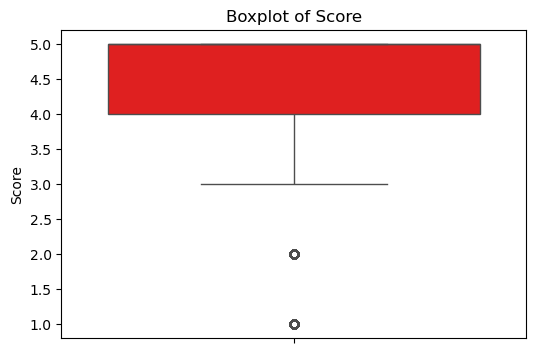

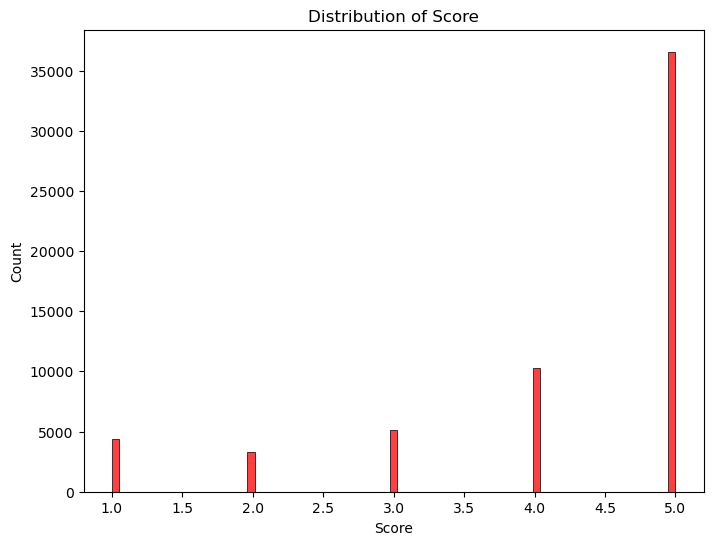

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59621 entries, 0 to 59620
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Score   59621 non-null  float64
 1   Text    59621 non-null  object 
dtypes: float64(1), object(1)
memory usage: 931.7+ KB


,Score,Text
0,4.0,"It is a nice made necklace, and the butterfly ..."
1,4.0,I bought this necklace on a whim; I love butte...
2,5.0,"Bought via gold box ,it is much better than I ..."
3,5.0,I love this necklace. It is great for everyday...
4,5.0,"Love this butterfly pendant. Right size, high ..."
...,...,...
58612,4.0,"When I first received this necklace, I was dis..."
58613,4.0,This is a very nice necklace it is a wonderful...
58618,5.0,"This necklace is beautiful. Of course, not on ..."
58619,5.0,"I bought this for my wife last year, still loo..."


In [2]:
#Initial EDA and data cleaning:

data = pd.read_csv("/Users/mukundranjan/Documents/Academics/Epiphany/Text Mining/Assignment/dataset.csv")      #Loading the dataset

data.head()
data.describe().transpose()

print(data.isnull().sum())   #Checking for missing values  

data["Score"].fillna(data["Score"].median(), inplace=True)   #Replacing missing values in both columns with either median or placeholder text (depending on the column)
data["Text"].fillna("No review available", inplace=True)


print(data.isnull().sum())    #Final check to ensure missing values have been dealt with. 

#Plotting distributions:
plt.figure(figsize=(6,4))
sns.boxplot(data["Score"], color="red")
plt.title("Boxplot of Score")
plt.show()
plt.figure(figsize=(8,6))
sns.histplot(data["Score"], color="red")
plt.title("Distribution of Score")
plt.show()

data.info()

#Dropping duplicates:
data.drop_duplicates()






# Text Pre-Processing and T-T Split

### Conversion to lowercase, removal of stopwords and punctuation, etc.

In [3]:

# Lowercasing, removing stopwords and punctuation, tokenising, and lemmatising the words:

data["Text"] = data["Text"].str.lower() # Lowercasing
stopwords_english = stopwords.words('english')
plist = list(punctuation)

def preprocessor(text):            #Tokensising + removing stopwords and lemmatising in a function.
    pres = []
    words = word_tokenize(text)
    wnl = WordNetLemmatizer()    #Creating a lemmatiser object to reduce the words to their lemmas


    for w in words:
        if ((w not in stopwords_english) and (w not in plist)):
            pres.append(wnl.lemmatize(w))      #Applying the lemmatizer to the filtered and processed words.

    return ' '.join(pres)                      #Adding a space whilst joining the processed sentences column to the main dataframe.

data["processed"] = data["Text"].apply(preprocessor)       #Applying the preprocessor function to carry out the neessary text processing.

data["Score"] = data["Score"].astype(int)                  #Converting Score from float to int, to focus on classification.





### Creating a Train-Test Split (80-20)

In [5]:
X = data["processed"]          #Predictor 
y = data["Score"]              #Response variable

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, stratify=y,random_state=42)     #Creating a Train-Test split with 20% of the data for testing, and the rest for training. 
#It is stratified to ensure the distribution of the response remains intact in both sets

print(f'Train-Test Split Complete. \n')
print(f'Train: {X_train.shape}; Test: {X_test.shape}')                                                                    #Printing shapes for visual confirmation that the train-test split was successful.

Train-Test Split Complete. 

Train: (47696,); Test: (11925,)


# Classification via Naïve-Bayes

Accuracy = 0.6720 

Precision = 0.6409 

Recall = 0.3458 

F1-Score = 0.3813 

Classification Report: 

              precision    recall  f1-score   support

           1       0.76      0.37      0.50       881
           2       0.71      0.08      0.14       657
           3       0.63      0.14      0.23      1026
           4       0.42      0.16      0.23      2048
           5       0.69      0.98      0.81      7313

    accuracy                           0.67     11925
   macro avg       0.64      0.35      0.38     11925
weighted avg       0.64      0.67      0.60     11925



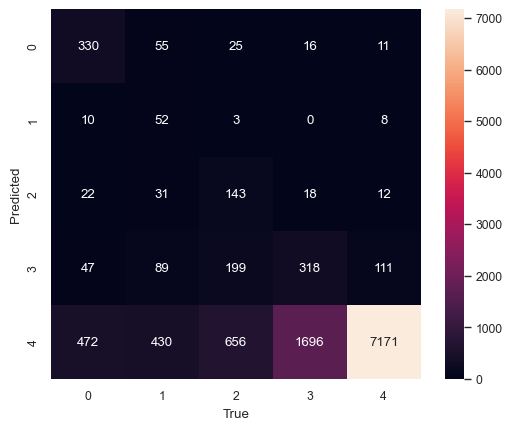

In [104]:
#Using TF-IDF Vectorization to Vectorise the Train and Test sets for Naïve Bayes... 
NBmodel = make_pipeline(TfidfVectorizer(max_features=5000), MultinomialNB())                             #...fitting the TF-TDF transformed set on the NB model in a single pipeline
NBmodel.fit(X_train, y_train)

yPredNB =NBmodel.predict(X_test)                #Making predictions

NB_acc = accuracy_score(y_test, yPredNB)              #Printing evaluation metrics
NB_rec = recall_score(y_test, yPredNB, average="macro")
NB_prec = precision_score(y_test, yPredNB, average="macro")
NB_f1 = f1_score(y_test, yPredNB, average="macro")
print(f'Accuracy = {NB_acc:.4f} \n')
print(f'Precision = {NB_prec:.4f} \n')
print(f'Recall = {NB_rec:.4f} \n')
print(f'F1-Score = {NB_f1:.4f} \n')
print("Classification Report: \n")
creport = classification_report(y_test, yPredNB)
print(creport)

#Computing and plotting the Confusion Matrix
cmatrix = confusion_matrix(y_test, yPredNB)
sns.heatmap(cmatrix.T, square = True, annot=True, fmt = "d")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()



with open('NBModel.pkl', 'wb') as f:                   #Saving the model via pickle for later use 
    pickle.dump(NBmodel, f)



# Classification via K-Nearest Neighbours (KNN)

KNN for k = 1:
Accuracy = 0.6545 

Precision = 0.4909 

Recall = 0.4627 

F1-Score = 0.4753 

Classification Report: 

              precision    recall  f1-score   support

           1       0.51      0.42      0.46       881
           2       0.36      0.32      0.34       657
           3       0.39      0.37      0.38      1026
           4       0.42      0.38      0.40      2048
           5       0.78      0.83      0.80      7313

    accuracy                           0.65     11925
   macro avg       0.49      0.46      0.48     11925
weighted avg       0.64      0.65      0.65     11925



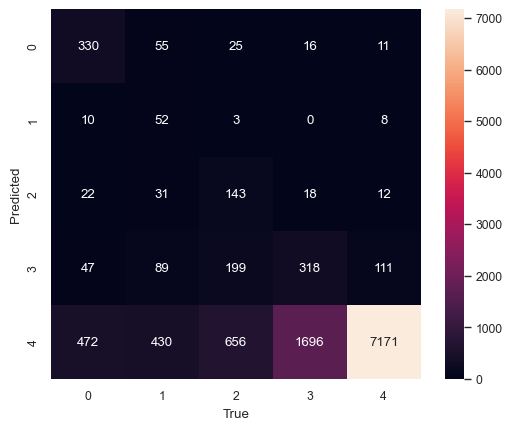

KNN for k = 2:
Accuracy = 0.5995 

Precision = 0.4371 

Recall = 0.4793 

F1-Score = 0.4535 

Classification Report: 

              precision    recall  f1-score   support

           1       0.41      0.52      0.46       881
           2       0.27      0.35      0.31       657
           3       0.32      0.39      0.35      1026
           4       0.35      0.42      0.38      2048
           5       0.83      0.71      0.77      7313

    accuracy                           0.60     11925
   macro avg       0.44      0.48      0.45     11925
weighted avg       0.64      0.60      0.62     11925



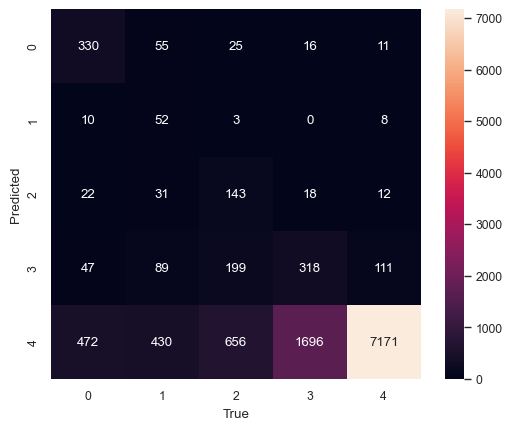

KNN for k = 3:
Accuracy = 0.6554 

Precision = 0.4656 

Recall = 0.4510 

F1-Score = 0.4524 

Classification Report: 

              precision    recall  f1-score   support

           1       0.41      0.49      0.45       881
           2       0.30      0.30      0.30       657
           3       0.38      0.33      0.36      1026
           4       0.46      0.28      0.34      2048
           5       0.78      0.86      0.82      7313

    accuracy                           0.66     11925
   macro avg       0.47      0.45      0.45     11925
weighted avg       0.63      0.66      0.64     11925



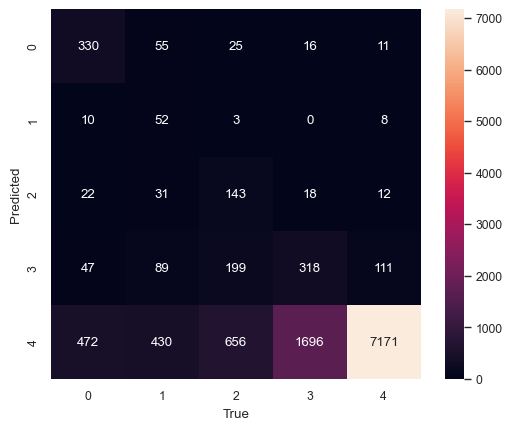

KNN for k = 4:
Accuracy = 0.6579 

Precision = 0.4927 

Recall = 0.4410 

F1-Score = 0.4601 

Classification Report: 

              precision    recall  f1-score   support

           1       0.47      0.46      0.47       881
           2       0.37      0.24      0.29       657
           3       0.46      0.31      0.37      1026
           4       0.41      0.34      0.37      2048
           5       0.76      0.86      0.81      7313

    accuracy                           0.66     11925
   macro avg       0.49      0.44      0.46     11925
weighted avg       0.63      0.66      0.64     11925



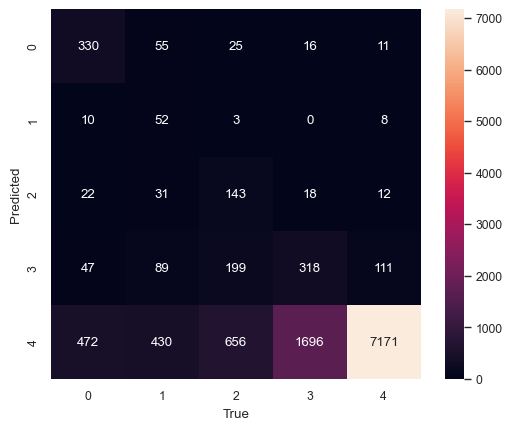

KNN for k = 5:
Accuracy = 0.6681 

Precision = 0.4993 

Recall = 0.4293 

F1-Score = 0.4546 

Classification Report: 

              precision    recall  f1-score   support

           1       0.51      0.42      0.46       881
           2       0.38      0.23      0.28       657
           3       0.43      0.31      0.36      1026
           4       0.43      0.31      0.36      2048
           5       0.76      0.89      0.82      7313

    accuracy                           0.67     11925
   macro avg       0.50      0.43      0.45     11925
weighted avg       0.63      0.67      0.64     11925



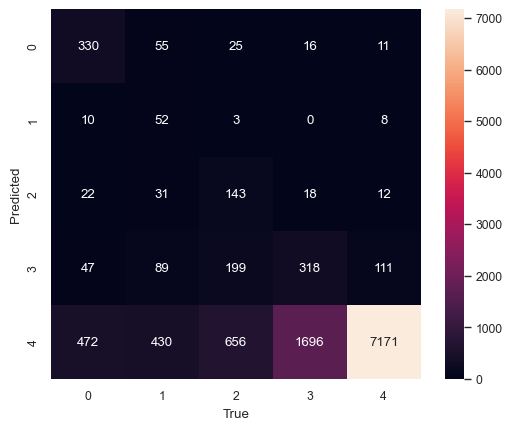

KNN for k = 6:
Accuracy = 0.6646 

Precision = 0.4960 

Recall = 0.4207 

F1-Score = 0.4468 

Classification Report: 

              precision    recall  f1-score   support

           1       0.50      0.41      0.45       881
           2       0.39      0.22      0.28       657
           3       0.42      0.28      0.34      1026
           4       0.42      0.29      0.34      2048
           5       0.75      0.89      0.82      7313

    accuracy                           0.66     11925
   macro avg       0.50      0.42      0.45     11925
weighted avg       0.63      0.66      0.64     11925



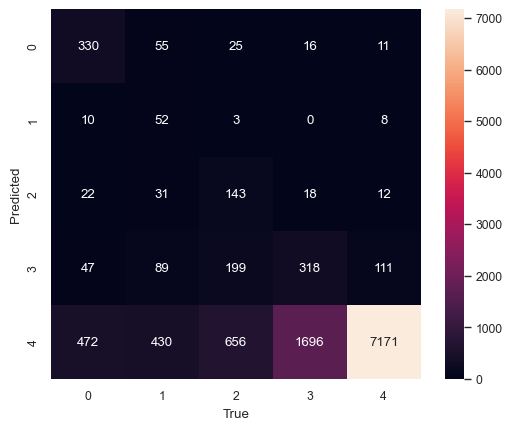

KNN for k = 7:
Accuracy = 0.6696 

Precision = 0.5063 

Recall = 0.4093 

F1-Score = 0.4397 

Classification Report: 

              precision    recall  f1-score   support

           1       0.53      0.40      0.46       881
           2       0.38      0.20      0.26       657
           3       0.45      0.26      0.33      1026
           4       0.44      0.26      0.33      2048
           5       0.74      0.91      0.82      7313

    accuracy                           0.67     11925
   macro avg       0.51      0.41      0.44     11925
weighted avg       0.63      0.67      0.63     11925



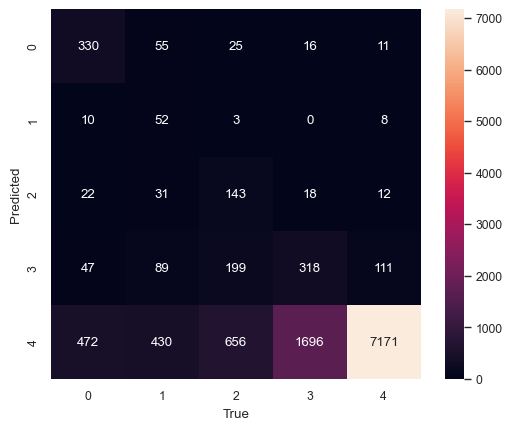

KNN for k = 8:
Accuracy = 0.6678 

Precision = 0.5139 

Recall = 0.4066 

F1-Score = 0.4395 

Classification Report: 

              precision    recall  f1-score   support

           1       0.55      0.40      0.46       881
           2       0.41      0.20      0.27       657
           3       0.45      0.25      0.32      1026
           4       0.43      0.27      0.33      2048
           5       0.73      0.91      0.81      7313

    accuracy                           0.67     11925
   macro avg       0.51      0.41      0.44     11925
weighted avg       0.62      0.67      0.63     11925



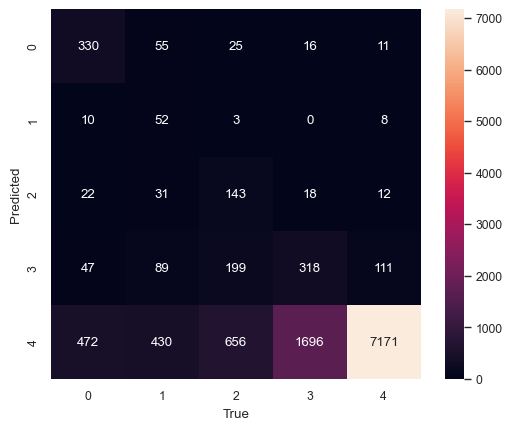

KNN for k = 9:
Accuracy = 0.6724 

Precision = 0.5190 

Recall = 0.4015 

F1-Score = 0.4357 

Classification Report: 

              precision    recall  f1-score   support

           1       0.55      0.38      0.45       881
           2       0.41      0.20      0.27       657
           3       0.46      0.25      0.32      1026
           4       0.45      0.24      0.32      2048
           5       0.73      0.93      0.82      7313

    accuracy                           0.67     11925
   macro avg       0.52      0.40      0.44     11925
weighted avg       0.63      0.67      0.63     11925



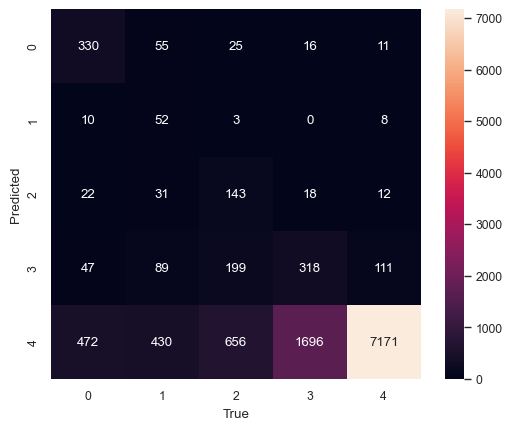

In [72]:
k_vals = [1, 2, 3, 4, 5, 6, 7, 8, 9]    #List of K-values to try for to find best K. I have chosen numbers from 1-9, which I can tune as I see fit after observing results
k_acc = []                              #Empty list of dictionaries to store K values and their associated accuracy scores for plotting later. 
for k in k_vals:
    KNNmodel = make_pipeline(TfidfVectorizer(max_features=5000), KNeighborsClassifier(n_neighbors=k))     #As before, the text is embedded via TF-IDF and then the KNN classifier is applied in the loop for varying values of K.
    KNNmodel.fit(X_train, y_train)
    yPredKNN = KNNmodel.predict(X_test)
    KNN_acc = accuracy_score(y_test, yPredKNN)                                                             #At each step, the model is fitted and the evaluation metric as well as the confusion matrix is computed and displayed/plotted.
    KNN_rec = recall_score(y_test, yPredKNN, average="macro")
    KNN_prec = precision_score(y_test, yPredKNN, average="macro")
    KNN_f1 = f1_score(y_test, yPredKNN, average="macro")

    k_acc.append({"K":k,
                  "Accuracy": KNN_acc})         #Appending Ks and their associated accuracy scores to the empty list initialised earlier.

    print(f"KNN for k = {k}:")                 #Printing metrics.
    print(f'Accuracy = {KNN_acc:.4f} \n')
    print(f'Precision = {KNN_prec:.4f} \n')
    print(f'Recall = {KNN_rec:.4f} \n')
    print(f'F1-Score = {KNN_f1:.4f} \n')
    print("Classification Report: \n")
    creport = classification_report(y_test, yPredKNN)
    print(creport)

    cmatrix = confusion_matrix(y_test, yPredNB)                       #Computing and plotting the confusion matrix.
    sns.heatmap(cmatrix.T, square = True, annot=True, fmt = "d")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.show()


#From the testing above, we can see that the KNN for K=9 is the best model. This is the model that is saved:
k9model = make_pipeline(TfidfVectorizer(max_features=5000), KNeighborsClassifier(n_neighbors=9))
k9model.fit(X_train, y_train)
yPredK9 = k9model.predict(X_test)

with open('KNNmodel.pkl', 'wb') as f:
    pickle.dump(k9model, f)





## Graph of Accuracy over Ks

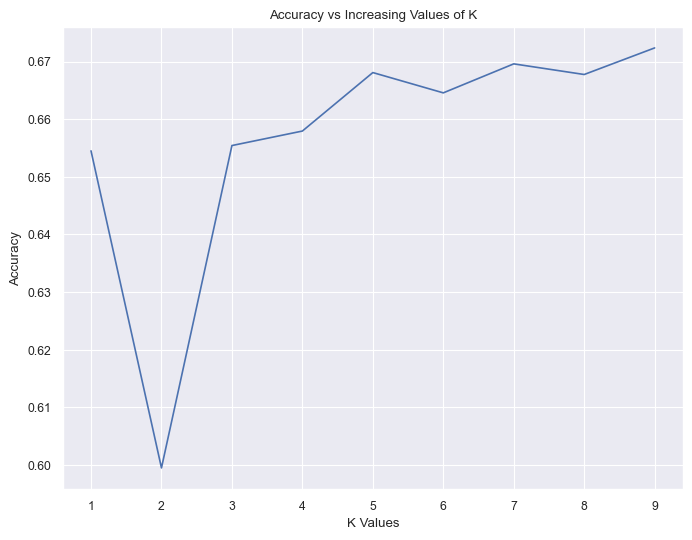

Classification Report: 

              precision    recall  f1-score   support

           1       0.55      0.38      0.45       881
           2       0.41      0.20      0.27       657
           3       0.46      0.25      0.32      1026
           4       0.45      0.24      0.32      2048
           5       0.73      0.93      0.82      7313

    accuracy                           0.67     11925
   macro avg       0.52      0.40      0.44     11925
weighted avg       0.63      0.67      0.63     11925



In [74]:
k_acc_df = pd.DataFrame(k_acc)        #Converting the list of dictionaries to a Pandas dataframe for plotting.
plt.figure(figsize=(8,6))
sns.set_theme("paper")
sns.lineplot(x=k_acc_df["K"], y=k_acc_df["Accuracy"], markers='x')           #Plotting the lineplot with the requisite values for X and Y axis.
plt.title("Accuracy vs Increasing Values of K")
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.show()

#Final Model Metrics:
print("Classification Report: \n")
creport_k9 = classification_report(y_test, yPredK9)
print(creport_k9)


# Creating a Google News Word2Vec Embedding

In [6]:
word2vec = api.load("word2vec-google-news-300")



# Long Short-Term Memory (LSTM) Model for Classification

## Building and Tuning the Model

Epoch 1/25


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


597/597 ━━━━━━━━━━━━━━━━━━━━ 185s 306ms/step - accuracy: 0.6021 - loss: 1.1017 - val_accuracy: 0.6754 - val_loss: 0.8288
Epoch 2/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 193s 323ms/step - accuracy: 0.6744 - loss: 0.8396 - val_accuracy: 0.6966 - val_loss: 0.7795
Epoch 3/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 191s 320ms/step - accuracy: 0.6912 - loss: 0.7945 - val_accuracy: 0.7051 - val_loss: 0.7600
Epoch 4/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 192s 322ms/step - accuracy: 0.7114 - loss: 0.7468 - val_accuracy: 0.7101 - val_loss: 0.7356
Epoch 5/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 195s 326ms/step - accuracy: 0.7136 - loss: 0.7253 - val_accuracy: 0.7121 - val_loss: 0.7366
Epoch 6/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 193s 323ms/step - accuracy: 0.7258 - loss: 0.7001 - val_accuracy: 0.7154 - val_loss: 0.7295
Epoch 7/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 197s 329ms/step - accuracy: 0.7312 - loss: 0.6809 - val_accuracy: 0.7202 - val_loss: 0.7205
Epoch 8/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 196s 328ms/step - accuracy: 0.7375 - loss: 0.66

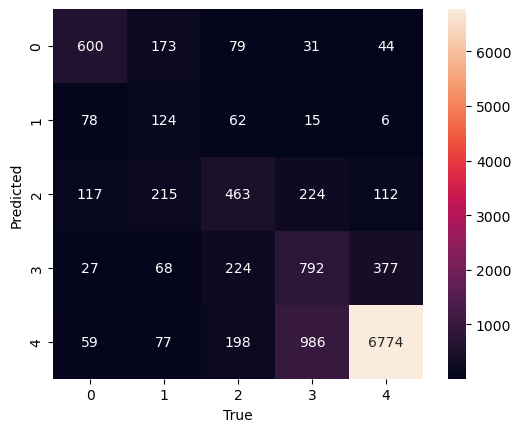

In [12]:
y_train_lstm = y_train - 1      #Setting up the test set (ratings are 1-5 not 0-4)
y_test_lstm = y_test - 1

MAX_VOCABULARY_WORDS = 25000 #Tokenization parameters
MAX_SEQUENCE_LENGTH = 500    #Size of the word sequence used to train. Values are manually tuned via hit-and-trial.
EMBEDDING = 70               ##Size of the embedding. Values are manually tuned via hit-and-trial.

#Vectorization layer to vectorize words followed by embedding layer to map them to numeric representations for the artificial neurons:
vectorize_layer = TextVectorization(max_tokens=MAX_VOCABULARY_WORDS, output_mode='int', output_sequence_length= MAX_SEQUENCE_LENGTH)
vectorize_layer.adapt(X_train)
vocabulary = vectorize_layer.get_vocabulary()

LSTMmodel = Sequential(name = "LSTM")
LSTMmodel.add(Input(shape=(1,), dtype=tf.string))
LSTMmodel.add(vectorize_layer)

#Embedding Layer:
#Embedding Matrix for Keras

EMBEDDING_DIM = 300  # Google Word2Vec uses 300D
embedding_matrix = np.zeros((len(vocabulary), EMBEDDING_DIM))

for i, word in enumerate(vocabulary):
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]



EMBEDDING_DIM = 300  # Google Word2Vec uses 300D
embedding_matrix = np.zeros((len(vocabulary), EMBEDDING_DIM))

for i, word in enumerate(vocabulary):
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]

embedding_layer = Embedding(input_dim=len(vocabulary),
                            output_dim=EMBEDDING_DIM,
                            weights=[embedding_matrix],  # Use Word2Vec weights
                            input_length=MAX_SEQUENCE_LENGTH,
                            trainable=False)  # Freeze Word2Vec weights




LSTMmodel.add(embedding_layer)
LSTMmodel.add(BatchNormalization())
#LSTM Layer 1:
LSTMmodel.add(Bidirectional(LSTM(16, return_sequences=True)))     #return_sequences = 2 allows us to add more layers below to capture more intricate word-meaning relationships.

#LSTM Layer 2:
LSTMmodel.add(Bidirectional(LSTM(16, dropout=0.2)))      #20% dropout to prevent overfitting over 16 Bidirectional LSTM cells.

#Regularization Layer:
LSTMmodel.add(Dropout(0.5))

#Dense layer as fully connected layer.
LSTMmodel.add(Dense(5, activation='softmax'))         #Final layer that recieves outputs from previous layers and makes predictions from outputs, with 5 layers. 
#Softmax is used in the output layer for multiclass classification
LSTMmodel.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])       #Loss is sparse_categorical for classification. Hyperparameters tuned manually via hit-and-trial (as above)

EPOCHS = 25                      #No of training cycles before the training terminates.
BATCH_SIZE = 64                  #Number of training samples processed before updating weights during the fitting process. Tuned manually via hit and trial. Lower batch sizes led to slower model training with little to no gain in accuracy metrics.


earlystopper = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode="auto")    #Stops the code early if 2 val accuracy scores converge to save compute and time.

history_lstm = LSTMmodel.fit(X_train.astype(str).to_numpy(), y_train_lstm.to_numpy(), epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, callbacks=[earlystopper])    #Fitting the model to the training data, setting hyperparameters and...
#...ensuring it stops early if convergeance is achieved before reaching the final epoch.


#Evaluating performance, and printing metrics:
yPred_LSTM = LSTMmodel.predict(X_test.astype(str).to_numpy())
yPred_LSTM = np.argmax(yPred_LSTM, axis=1)
LSTM_acc = accuracy_score(y_test_lstm, yPred_LSTM)
LSTM_rec = recall_score(y_test_lstm, yPred_LSTM, average="weighted")
LSTM_prec = precision_score(y_test_lstm, yPred_LSTM, average="weighted")
LSTM_f1 = f1_score(y_test_lstm, yPred_LSTM, average="weighted")
print("Evaluation Metrics for LSTM: \n")
print(f'Accuracy = {LSTM_acc:.4f} \n')
print(f'Precision = {LSTM_prec:.4f} \n')
print(f'Recall = {LSTM_rec:.4f} \n')
print(f'F1-Score = {LSTM_f1:.4f} \n')
print("Classification Report: \n")
creport_lstm = classification_report(y_test_lstm, yPred_LSTM)
print(creport_lstm)

#Computing and Plotting Confusion Matrix:
cmatrix_lstm = confusion_matrix(y_test_lstm, yPred_LSTM)
sns.heatmap(cmatrix_lstm.T, square = True, annot=True, fmt = "d")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()


#Saving the model:
with open('LSTM.pkl', 'wb') as f:
    pickle.dump(LSTMmodel, f)

# Convolutional Neural Network (CNN) Model for Classification

## Building and Tuning the Model

Epoch 1/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 66s 108ms/step - accuracy: 0.4940 - loss: 1.3824 - val_accuracy: 0.6936 - val_loss: 0.7960
Epoch 2/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 66s 111ms/step - accuracy: 0.6967 - loss: 0.7870 - val_accuracy: 0.7111 - val_loss: 0.7507
Epoch 3/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 77s 128ms/step - accuracy: 0.7225 - loss: 0.7178 - val_accuracy: 0.7210 - val_loss: 0.7360
Epoch 4/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 73s 123ms/step - accuracy: 0.7470 - loss: 0.6589 - val_accuracy: 0.7321 - val_loss: 0.7050
Epoch 5/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 73s 122ms/step - accuracy: 0.7621 - loss: 0.6149 - val_accuracy: 0.7260 - val_loss: 0.7303
Epoch 6/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 70s 117ms/step - accuracy: 0.7792 - loss: 0.5630 - val_accuracy: 0.7232 - val_loss: 0.7269
Epoch 7/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 69s 115ms/step - accuracy: 0.8046 - loss: 0.5146 - val_accuracy: 0.7231 - val_loss: 0.7472
Epoch 8/25
597/597 ━━━━━━━━━━━━━━━━━━━━ 70s 116ms/step - accuracy: 0.8165 - loss: 0

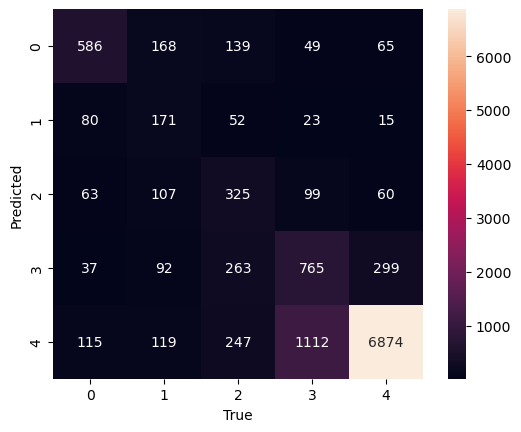

In [13]:
y_train_cnn = y_train - 1      #Setting up the test set (ratings are 1-5 not 0-4)
y_test_cnn = y_test - 1

MAX_VOCABULARY_WORDS = 25000 #Tokenization parameters
MAX_SEQUENCE_LENGTH = 500    #Size of the word sequence used to train. Values are manually tuned via hit-and-trial.
EMBEDDING = 70                   #Size of the embedding. Values are manually tuned via hit-and-trial.

#Vectorization layer to vectorize words and map them to numeric representations for the neurons:
vectorize_layer = TextVectorization(max_tokens=MAX_VOCABULARY_WORDS, output_mode='int', output_sequence_length= MAX_SEQUENCE_LENGTH)
vectorize_layer.adapt(X_train)
vocabulary = vectorize_layer.get_vocabulary()

CNNmodel = Sequential(name = "CNN")
CNNmodel.add(Input(shape=(1,), dtype=tf.string))
CNNmodel.add(vectorize_layer)
#Embedding Layer:
CNNmodel.add(embedding_layer)

#CNN Layer 1:
CNNmodel.add(Conv1D(filters=128,kernel_size=5, activation='relu'))  #1 Dimensional CNN layer with 128 filters and ReLU activation over a sliding window of 5 to capture finer details in word-word relationships.
#CNN Layer 2:
CNNmodel.add(Conv1D(filters=64,kernel_size=5, activation='relu'))    #1 Dimensional CNN layer with 64 filters and ReLU activation over a sliding window of 5 to capture finer details in word-word relationships.

CNNmodel.add(GlobalMaxPooling1D())       #Flattening by selecting only the most relevant features

CNNmodel.add(BatchNormalization())
#Regularization:
CNNmodel.add(Dropout(0.5))

#Dense layer as fully connected layer:
CNNmodel.add(Dense(5, activation='softmax'))     #Final layer that recieves outputs from previous layers and makes predictions from outputs, with 5 layers. 
#ReLU was used earlier to fire neurons more freely and explosively. Softmax is used in the output layer for multiclass classification
CNNmodel.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])  #Sparse Categorical is used as our objective is classification.

EPOCHS = 25            #No of training cycles before the training terminates.
BATCH_SIZE = 64        #Number of training samples processed before updating weights during the fitting process. Tuned manually via hit and trial. Lower batch sizes led to slower model training with little to no gain in accuracy metrics.

earlystopper = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, mode="auto")   #Early stopper stops early if convergeance is acheived (3 consective val accuracy scores match). Same as LSTM previously.

history_cnn = CNNmodel.fit(X_train.astype(str).to_numpy(), y_train_cnn.to_numpy(), epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, callbacks=[earlystopper])    #Fitting the model with tuned hyperparameters.


#Evaluating Performance:
yPred_CNN = CNNmodel.predict(X_test.astype(str).to_numpy())
yPred_CNN = np.argmax(yPred_CNN, axis=1)
CNN_acc = accuracy_score(y_test_cnn, yPred_CNN)
CNN_rec = recall_score(y_test_cnn, yPred_CNN, average="weighted")
CNN_prec = precision_score(y_test_cnn, yPred_CNN, average="weighted")
CNN_f1 = f1_score(y_test_cnn, yPred_CNN, average="weighted")
print("Evaluation Metrics for LSTM: \n")
print(f'Accuracy = {CNN_acc:.4f} \n')
print(f'Precision = {CNN_prec:.4f} \n')
print(f'Recall = {CNN_rec:.4f} \n')
print(f'F1-Score = {CNN_f1:.4f} \n')
print("Classification Report: \n")
creport_cnn = classification_report(y_test_cnn, yPred_CNN)
print(creport_cnn)

#Computing and Plotting Confusion Matrix:
cmatrix_cnn = confusion_matrix(y_test_cnn, yPred_CNN)
sns.heatmap(cmatrix_cnn.T, square = True, annot=True, fmt = "d")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()


#Saving the model:
with open('CNN.pkl', 'wb') as f:
    pickle.dump(CNNmodel, f)

# Model Summaries for the CNN and LSTM

In [13]:
CNNmodel.summary()

LSTMmodel.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 300)       │     7,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 496, 128)       │       192,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 492, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,200,433 (31.28 MB)

 Trainable params: 233,477 (912.02 KB)

 Non-trainable params: 7,500,000 (28.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 300)       │     7,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 32)        │        40,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,641,041 (29.15 MB)

 Trainable params: 47,013 (183.64 KB)

 Non-trainable params: 7,500,000 (28.61 MB)

 Optimizer params: 94,028 (367.30 KB)

# Predicting Product Ratings (Lone Cell):

In [14]:
def predict_product_rating(text, model):
    model = model + '.pkl'       #Adding .pkl at the end of the filename to ensure that the correct file is called

    # The code below calls models based on the name entered by the users (with .pkl suffixed to ensure filename matching). Based on the call, the appropriate model
    # Is called and loaded, and a prediction is made. Finally a message outputs the name of the model and the rating it predicted based on the sample text passed into the function.


    if model == 'NBModel.pkl':
        txt = pd.Series(text)                                 #The model expects a Pandas series, hence the conversion. This is repeated for all models.
        model_load = pickle.load(open('NBModel.pkl', 'rb'))
        rating = model_load.predict(txt)
        print("The Naïve Bayes model predicts a product rating of - ", rating[0])
    elif model == 'KNNmodel.pkl':
        txt = pd.Series(text)
        model_load = pickle.load(open('KNNmodel.pkl', 'rb'))
        rating = model_load.predict(txt)
        print("The K-Nearest Neighbours model (with K=9) predicts a product rating of - ", rating[0])
    elif model == "CNN.pkl":
        txt = pd.Series(text)
        model_load = pickle.load(open('CNN.pkl', 'rb'))
        rating = model_load.predict(txt.astype(str).to_numpy())
        rating_output_neural = np.argmax(rating) + 1              #Outputting the rating with the highest probability, and adding 1 to adjust for the 1-5 rating system (output is 0-4) 
        print("The Convolutional Neural Network model predicts a product rating of - ", rating_output_neural)
    elif model == "LSTM.pkl":
        txt = pd.Series(text)
        model_load = pickle.load(open('LSTM.pkl', 'rb'))
        rating = model_load.predict(txt.astype(str).to_numpy())
        rating_output_neural = np.argmax(rating) + 1              #Outputting the rating with the highest probability, and adding 1 to adjust for the 1-5 rating system (output is 0-4)
        print("The Long Short Term Memory model predicts a product rating of - ", rating_output_neural)
    else:
        print("INVALID INPUT. NO SUCH MODEL FOUND!")               #Accounting for user error.





### Running the 'predict_product_ratings' Function to Make Predictions:

In [16]:
text = "This poduct is decent. It is alright."   #Sample text for testing.
print("The avaialable models are KNNmodel, NBmodel, CNN and LSTM. Please type the name of one of these models below (case-sensitive):\n")    #Asking user to input the name of their desired model.
model = input()                          #Taking the input
predict_product_rating(text, model)      #Calling the prediction function defined earlier to make a prediction based on the user's choice of model.    


The avaialable models are KNNmodel, NBmodel, CNN and LSTM. Please type the name of one of these models below (case-sensitive):

The K-Nearest Neighbours model (with K=9) predicts a product rating of -  5


### ----------------------------------------------------------------------------------------------------------------------------

# ***Report***

### **1.  Dataset Description and Exploratory Analysis**

The given dataset (file name - `dataset.csv`) is a .csv file consisting of 59,622 reviews and ratings for products from the ecommerce website, Amazon. These are divided into two columns – `Score`, containing a numeric score in the range of 1 to 5, and `Text`, a string with the associated review of the product. Our goal is to create 4 classification models to predict the `Score` of a given item given its review, based on this dataset. Initial inspections reveal key insights about the dataset. The score column consisted of float values while the text value consisted of strings. Multiple values were found to be missing from either column. These were imputed – scores were imputed by replacing missing values with the median of the score column, while missing `Text` column values were replaced with placeholder text. 14,377 values were found to be duplicates – these were eliminated using a suitable duplicate removal function found in Pandas.  The distribution was plotted via histograms both before and after these cleaning steps – it was found to be intact even after the data cleaning procedures.  Further investigations were done via the use of boxplots. Both these visualizations revealed a severe class imbalance, with 5-star reviews massively dominating the dataset (>30,000 instances; the reviews from 1-4 had less than 25,000 instances cumulatively!). This makes the dataset prone to inducing bias when utilized in machine learning models; however, with careful preprocessing and hyperparameter tuning, the dataset can be viably utilized for these models. The dataset consists of a very large  number of reviews, and each of these reviews (after cleaning, as detailed above) provide a variety of tonal and linguistic variations – these patterns can be effectively exploited with careful tweaking to create powerful prediction algorithms. 

### **2. Data Preperation, Text Preprocessing and the Train-Test Split**

The dataset undergoes several preprocessing steps, before being split into a training set and test set. These steps are as follows:
1.	**Lowercasing** – In this step, all letters in the strings are reduced to lowercase. This is done to ensure that there is a certain degree of consistency, and that case-sensitivity does not make the algorithms treat the same word as two different words with different meanings. 
2.	**Stopword and Punctuation Removal** – This step is done to reduce dimensionality (excess stopwords like the, in, etc.) and noise (punctuation marks). Stopwords add little to no semantic value once words are transformed into their embeddings for training in the models.
3.	**Tokenization** – This step is done to break sentences down into individual words, to make it easier for the algorithms to learn word meanings by being fed individual words for training. 
4.	**Lemmatization** – Certain words (such as buying, working, running, etc.) are reduced to their lemmas (buy, work, run respectively). This further reduces dimensionality, improves training speed and reduces memory use without losing semantic information and generalization ability.


These steps are carried out in a function and then joined to the main dataset to restore `Score`-`Text` associations. Further processing is done on the `Score` column, converting the `float` values to `int` values so as to aid classification and prevent the prediction of intermediate `floating-point` `Score` values. These steps are undertaken to ensure that we have a clean, high-quality, and denoised set of standardized data that is ready to be fed into a machine learning model for training and prediction, without eliminating potential errors and compatibility issues that may have arisen otherwise had we fed the algorithms raw, unprocessed data. This improves model performance and reduces the time needed for training by removing unnecessary information. Finally, after these preprocessing steps, the dataset is split into a training set and a test set in a 80-20 fashion, ensuring that the parameters for the split are tuned to account for the class imbalance. 


### **3. Machine Learning Architectures**

Four Machine Learning architectures were trained utilized to make predictions on sample input text. These were as follows:
1.	**Naïve Bayes**: 
The Naïve Bayes classifier is a probabilistic classifier that uses the principles of Bayes Theorem and assumes feature independence to estimate class probabilities based on the frequencies of words. Here, it used in a pipeline with a TF-IDF (Text Frequency-Inverse Document Frequency) vectorizer function to build a model that predicts the probabilities based on the TF-IDF feature frequencies. The text is first vectorized, then fit to a Naïve Bayes model via the MultinomialNB() function. TF-IDF is used as it reflects word importance, ensuring more important words hold greater weight during training.

2.	**K-Nearest Neighbours (KNN)**: 
The KNN classifier is a parametric model that uses the ‘k’ closest points (based on Euclidean distance) to extract feature similarity. This model also used the TF-IDF text representation in the pipeline in a similar fashion to naïve Bayes; the TF-IDF vectors were used by the KNN model to calculate distance measures via Cosine Similarity.  Here, the TF-IDF vectors ‘clump’ similar words closer to one another, aiding learning – hence its use. In the model, multiple values of k were used iteratively; the best value of k was selected based on evaluation metrics and saved. This was found to be k=9.

3.	 **Convolutional Neural Network (CNN)**:
A CNN simulates a human brain using artificial neurons that apply filters to extract hierarchical patterns from text. The CNN architecture includes a two-layer structure with vectorization, embedding, two convolutional layers (128 and 64 filters, capturing general trends and complex patterns with ReLU activation respectively), regularization for feature selection, and a fully-connected output layer using softmax for multiclass classification. Text representation utilized Keras' TextVectorization(), which preprocesses input text into standardized numeric sequences—chosen for being simple, fast, and effective for neural networks. Hyperparameters were manually tuned for optimal setup. Early stopping prevented wasting computation once convergence occurred. The model was compiled with sparse_categorical_crossentropy and optimized using Adam. Dropout was implemented to prevent overfitting due to class imbalance. This architecture enables efficient text classification by progressively extracting more sophisticated patterns while maintaining computational efficiency.. 

4.	**Long Short-Term Memory (LSTM) Network**:
LSTMs are variations of Recurrent Neural Networks that retain information over long periods, ensuring that gradient losses do not diminish performance over time. Much like the CNN described above, the LSTM used was also a 2 layer network with the Keras Sequential APIs inbuilt `TextVectorizer()` representation; however, the two convolutional layers were replaced with Bidirectional LSTM layers. These layers were set up with 16 units each – the first to capture long-term dependencies and the second to capture deeper relationships and short-term contexts. The bidirectional nature of the layers meant that each layer learns from the preceding and following context – while this added computational complexity, it allows for richer, sequential context identification and word-pattern recognition. Much like the CNN above, a dropout was applied to prevent overfitting along with an early stopping criterion. Hyperparameters were tuned manually over multiple runs, as above.



### **4. Model Performance Evaluation**

**Summary of Evaluation Metrics:**


| Model          | Accuracy | Precison | Recall     |    F1  |
|----------------|----------|----------|-----------|---------|
|  LSTM          |0.7330   |  0.7092  | 0.7239    | 0.7155  |
| CNN            | 0.7243   | 0.7050   | 0.7243    | 0.7035  |
| KNN            | 0.6724  | 0.5190   | 0.4015    | 0.4357  |
| Naïve Bayes    | 0.6720   | 0.6409   | 0.3458    | 0.3813  |


The LSTM outperformed the other models likely due to its bidirectional learning, allowing to capture greater context and more granular word-word associations. The next best model was the CNN, which captured general trends and layered them with deeper n-gram associations due to its second layer of 64 filters and a sliding window of 5 kernels. However, due to its unidirectional learning, it failed to pool as much semantic information as an LSTM. However, both neural networks performed well, with >70% accuracy and acceptable performance metrics across the board.

The KNN and Naïve Bayes model failed to perform as well as the neural networks; this is likely due to the comparatively simplistic nature of their learning methodologies and the use of sparse TF-IDF representations. The KNN performed better between the two though, with the model at K=9 neighbours yielding the best evaluative metrics. This is likely due to the ability clustered values based on Cosine distance  capture semantic context and word-word relations versus the simple Bayesian probability calculations of the Naïve Bayes. The performance of the models successfully demonstrates the ability of neural nets to capture richer context and deeper relationships versus more traditional methods.


### **5. Critical Discussion and Limitations**

While most models (particularly the neural nets) performed reasonably well across the board (especially in terms of Accuracy), the models were not exceptional. The traditional models – Naïve Bayes and KNN – suffered greatly. This was due to the severe class imbalance present in the dataset, observed from the very outset. While techniques such as stratification during the Train-Test Split, careful hyperparameter tuning, the use of pooling techniques and dense layers with dropout criterions and in-built imbalance handling protocols in the libraries used alleviated the fallout of this to some extent, it still played spoilsport with regards to the training. The traditional models seemed to suffer from this greatly, with significantly lower accuracy and terrible evaluative metrics. This shows that we can comfortably reject the traditional methods for this task, in favour of the more advanced neural networks. Furthermore, during the use of the model for predictions, while all models (particularly the two neural nets) predicted each class at least once over multiple trials, the vast majority of predictions predicted the majority class (5-star reviews) or the opposite extreme of 1-star reviews. Another limitation observed was with regards to the exacerbation of the weakness of Naïve Bayes and KNNs to capture richer patterns by the use of TF-IDF vectorization, a simplistic method in the face of more sophisticated text representation used by the neural networks. 

Future experiments with these methods for text classification should include suitable undersampling/oversampling techniques to address class imbalance, and the use of more complex pre-trained embeddings such as Word2Vec, GloVe, fastText, BERT, ELMo, etc. for word representations in the neural nets' embedding layers.


### **6. Usage Guide**

In order to use these models, the user is asked to run the `predict_product_ratings` function. This function takes two arguments - the name of the model (`string`) and a sample review text (also a `string`). Here, a sample string is provided while the user is asked to input the case-sensitive name of the model (as provided in the input prompt); in practical scenarios, the sample review text will also be entered by the user. The user has to enter one of the four provided model names (without the `.pkl` suffix; this is handled by the software to improve ease of use):

1. `NBModel.pkl` - The Naïve Bayes Classifier
2. `KNNmodel.pkl` - The K-Nearest Neighbours Classifier with K=9
3. `CNN.pkl` - The Convolutional Neural Network
4. `LSTM.pkl` - The Long Short-Term Memory model

Upon entering the name of the model, the function loads the model from internal storage, makes a prediction on the sample, and outputs the result.